# Default assumed user expertise — figures

Run top to bottom. Figures save to `results/`.

| exp | anchors | source |
|---|---|---|
| 1 | style-written expert/novice prompts | `data/acts.npz` |
| 2 | addressed suffixes, behavioural readout | `results/behavior.jsonl` |
| 3 | addressed suffixes, activation readout, presupposition-split | `results/probe2_positions.npz` |

In [1]:
%load_ext autoreload
%autoreload 2
import json, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr
from config import TOPICS, DATA, RESULTS
from probe2 import FAMILIES
import analyze as A

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
T = list(TOPICS); FAM = list(FAMILIES)
NOV, EXP, BEH, GREY = '#c0603a', '#3a6ea5', '#5b8c5a', '#bbbbbb'
FC = {'pre': '#7fa8d0', 'post': '#2a5580'}
RESULTS.mkdir(exist_ok=True)
rng = np.random.default_rng(0)

def boot(x, n=4000):
    x = np.asarray(x)
    return np.percentile(rng.choice(x, (n, len(x)), replace=True).mean(1), [2.5, 97.5])

def perm_p(groups, n=5000):
    obs = np.var([g.mean() for g in groups])
    flat, sz = np.concatenate(groups), [len(g) for g in groups]
    null = np.array([np.var([x.mean() for x in
                     np.split(rng.permutation(flat), np.cumsum(sz)[:-1])]) for _ in range(n)])
    return obs, (null >= obs).mean()

def decomp(d):
    within = np.mean([v.var(ddof=1) for v in d.values()])
    n = np.mean([len(v) for v in d.values()])
    mu = np.array([v.mean() for v in d.values()])
    return within, within / n, max(mu.var(ddof=1) - within / n, 0.0)

In [2]:
f = np.load(RESULTS / 'probe2_positions.npz')
auc2, L2 = f['aucs'], int(f['layer'])
pos = {tuple(k.split('|')): f[k] for k in f.files if '|' in k and not k.startswith('bow')}
bow = {k.split('|')[1]: f[k] for k in f.files if k.startswith('bow')}
both = {(t, fam): np.concatenate([pos[(t, fam, 'A')], pos[(t, fam, 'B')]])
        for t in T for fam in FAM}
print(f'layer {L2}, L0 AUC {auc2[0]:.3f}, peak {auc2.max():.3f}')

layer 19, L0 AUC 0.651, peak 1.000


## Fig 1 — the confound and the fix

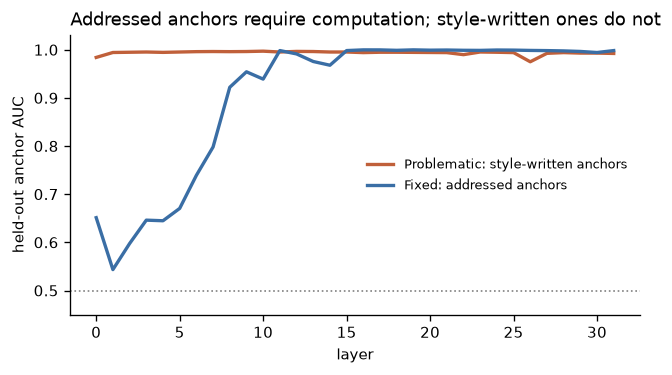

Problematic L0=0.984  Fixed L0=0.651


In [7]:
acts1, topic1, label1, idx1 = A.load(DATA / 'acts.npz')
sweep1 = A.layer_sweep(acts1, topic1, label1, idx1, T)
auc1 = sweep1.mean(1); L1 = int(auc1.argmax())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(auc1, lw=2, color=NOV, label='Problematic: style-written anchors')
ax.plot(auc2, lw=2, color=EXP, label='Fixed: addressed anchors')
ax.axhline(.5, ls=':', c='gray', lw=1)
ax.set_xlabel('layer'); ax.set_ylabel('held-out anchor AUC'); ax.set_ylim(.45, 1.03)
ax.legend(frameon=False, loc='center right', fontsize=8)
ax.set_title('Addressed anchors require computation; style-written ones do not', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig1_layer_sweep.png', bbox_inches='tight'); plt.show()
print(f'Problematic L0={auc1[0]:.3f}  Fixed L0={auc2[0]:.3f}')

## Fig 2 — presupposition effect (the manipulation)

pre   +0.194  [+0.180, +0.209]  sd 0.077
post  +0.383  [+0.348, +0.417]  sd 0.176
effect = +0.189


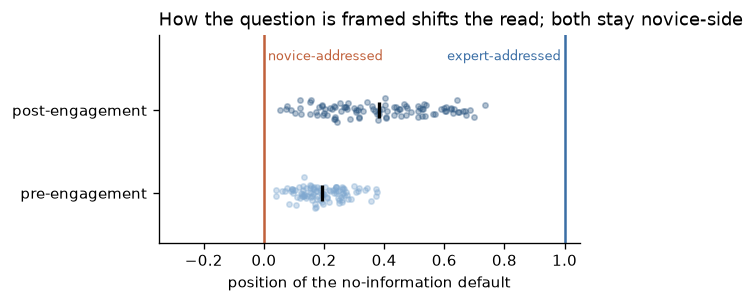

In [4]:
fv = {fam: np.concatenate([both[(t, fam)] for t in T]) for fam in FAM}
for fam in FAM:
    c = boot(fv[fam])
    print(f'{fam:5s} {fv[fam].mean():+.3f}  [{c[0]:+.3f}, {c[1]:+.3f}]  sd {fv[fam].std(ddof=1):.3f}')
print(f'effect = {fv["post"].mean() - fv["pre"].mean():+.3f}')

fig, ax = plt.subplots(figsize=(5, 2.6))
for i, fam in enumerate(FAM):
    ax.scatter(fv[fam], np.full(len(fv[fam]), i) + rng.normal(0, .06, len(fv[fam])),
               s=10, alpha=.35, color=FC[fam])
    ax.scatter([fv[fam].mean()], [i], s=90, marker='|', color='k', zorder=4, lw=2)
ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
ax.text(0, 1.6, ' novice-addressed', color=NOV, fontsize=8)
ax.text(1, 1.6, 'expert-addressed ', color=EXP, fontsize=8, ha='right')
ax.set_yticks(range(len(FAM))); ax.set_yticklabels(['pre-engagement', 'post-engagement'])
ax.set_xlim(-.35, 1.05); ax.set_ylim(-.6, 1.9)
ax.set_xlabel('position of the no-information default')
ax.set_title('How the question is framed shifts the read; both stay novice-side', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig2_presupposition.png', bbox_inches='tight'); plt.show()

In [8]:
from config import TOPICS
from probe2 import FAMILIES
for f, ts in FAMILIES.items():
    for tm in ts:
        for k, d in TOPICS.items():
            print(f"[{f}] {tm.format(t=d)}")
    print()


[pre] I'm about to get into sourdough bread baking again. What should I know going in?
[pre] I'm about to get into chemotherapy treatment decisions again. What should I know going in?
[pre] I'm about to get into python programming again. What should I know going in?
[pre] I'm about to get into mortgage refinancing again. What should I know going in?
[pre] I'm about to get into car engine repair again. What should I know going in?
[pre] I'm about to get into music theory and composition again. What should I know going in?
[pre] I'm about to get into personal income tax law again. What should I know going in?
[pre] I'm about to get into houseplant care again. What should I know going in?
[pre] I'm about to get into machine learning research again. What should I know going in?
[pre] I'm about to get into strength training programming again. What should I know going in?
[pre] I've got something coming up involving sourdough bread baking. Where should I start?
[pre] I've got something comin

## Fig 3 — domain, within each family

pre   within=0.0044 (sd 0.066)  between obs=0.00187 floor=0.00044 true=0.00164 (sd 0.040)  p=0.000
post  within=0.0277 (sd 0.167)  between obs=0.00559 floor=0.00277 true=0.00344 (sd 0.059)  p=0.025


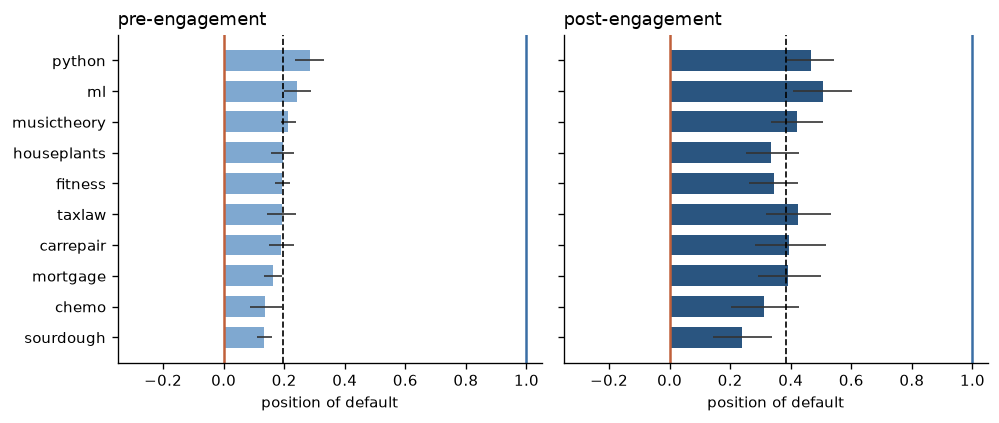

In [5]:
for fam in FAM:
    d = {t: both[(t, fam)] for t in T}
    w, floor, true_b = decomp(d)
    obs, p = perm_p([d[t] for t in T])
    print(f'{fam:5s} within={w:.4f} (sd {np.sqrt(w):.3f})  between obs={obs:.5f} '
          f'floor={floor:.5f} true={true_b:.5f} (sd {np.sqrt(true_b):.3f})  p={p:.3f}')

order = sorted(T, key=lambda t: both[(t, 'pre')].mean())
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharey=True)
for ax, fam in zip(axes, FAM):
    mu = np.array([both[(t, fam)].mean() for t in order])
    ci = np.array([boot(both[(t, fam)]) for t in order])
    ax.barh(range(len(order)), mu, color=FC[fam], height=.68,
            xerr=np.abs(ci.T - mu), error_kw=dict(lw=1, ecolor='#333'))
    ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
    ax.axvline(np.concatenate([both[(t, fam)] for t in T]).mean(), ls='--', c='k', lw=1)
    ax.set_xlim(-.35, 1.05); ax.set_title(fam + '-engagement', loc='left')
    ax.set_xlabel('position of default')
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order)
plt.tight_layout(); plt.savefig(RESULTS / 'fig3_domain.png', bbox_inches='tight'); plt.show()

## Fig 4 — controls: stability, template residual, BoW

paraphrase-set stability (same text, different anchors)
  pre   var(A vs B)=0.0000   vs within-topic 0.0062   ratio 0.00
  post  var(A vs B)=0.0007   vs within-topic 0.0184   ratio 0.04

template means within family
  pre   +0.10  How do I get started with {t}?
  pre   +0.17  What should I know before trying {t}?
  pre   +0.30  What's the first thing to do with {t}?
  pre   +0.12  Where do I begin with {t}?
  pre   +0.18  What do I need to know about {t}?
  post  +0.32  I tried {t} and it didn't go how I expected. Any ideas?
  post  +0.27  My {t} isn't working right. What should I check?
  post  +0.59  I've been doing {t} but something's off. Any thoughts?
  post  +0.51  I ran into a problem with {t}. What's likely going on?
  post  +0.38  {t} isn't behaving the way I thought. Where should I look?


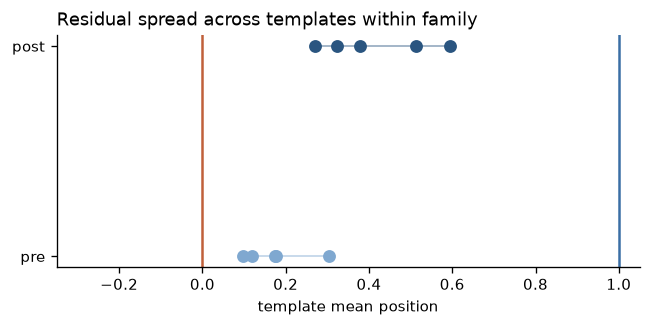

In [6]:
print('paraphrase-set stability (same text, different anchors)')
for fam in FAM:
    v = np.mean([np.var(np.stack([pos[(t, fam, 'A')], pos[(t, fam, 'B')]]), axis=0).mean()
                 for t in T])
    w, _, _ = decomp({t: both[(t, fam)] for t in T})
    print(f'  {fam:5s} var(A vs B)={v:.4f}   vs within-topic {w:.4f}   ratio {v/w:.2f}')

print('\ntemplate means within family')
tm = {}
for fam in FAM:
    v = np.stack([both[(t, fam)].reshape(2, -1).mean(0) for t in T])
    tm[fam] = v.mean(0)
    for i, s in enumerate(FAMILIES[fam]):
        print(f'  {fam:5s} {v[:, i].mean():+.2f}  {s}')

fig, ax = plt.subplots(figsize=(5.5, 2.8))
for i, fam in enumerate(FAM):
    ax.scatter(tm[fam], np.full(len(tm[fam]), i), s=45, color=FC[fam], zorder=3)
    ax.plot([tm[fam].min(), tm[fam].max()], [i, i], color=FC[fam], lw=1, alpha=.5)
ax.set_yticks(range(len(FAM))); ax.set_yticklabels(['pre', 'post'])
ax.set_xlabel('template mean position'); ax.set_xlim(-.35, 1.05)
ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
ax.set_title('Residual spread across templates within family', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig4_template_residual.png', bbox_inches='tight'); plt.show()

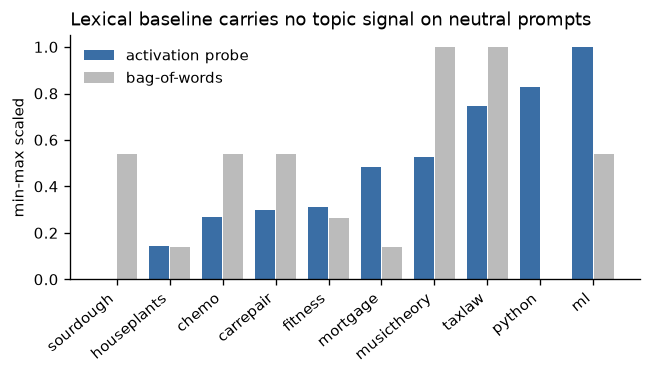

BoW raw range 0.0283   probe raw range 0.2119


In [7]:
def mm(v):
    v = np.asarray(v); return (v - v.min()) / (v.max() - v.min())
pv = mm([np.concatenate([both[(t, fam)] for fam in FAM]).mean() for t in T])
bv = mm([bow[t].mean() for t in T])
o = np.argsort(pv); x = np.arange(len(T))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(x - .2, pv[o], .38, color=EXP, label='activation probe')
ax.bar(x + .2, bv[o], .38, color=GREY, label='bag-of-words')
ax.set_xticks(x); ax.set_xticklabels([T[i] for i in o], rotation=40, ha='right')
ax.set_ylabel('min-max scaled'); ax.legend(frameon=False)
ax.set_title('Lexical baseline carries no topic signal on neutral prompts', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig5_bow_control.png', bbox_inches='tight'); plt.show()
raw = [bow[t].mean() for t in T]
print(f'BoW raw range {max(raw)-min(raw):.4f}   probe raw range '
      f'{max(np.concatenate([both[(t,f)] for f in FAM]).mean() for t in T) - min(np.concatenate([both[(t,f)] for f in FAM]).mean() for t in T):.4f}')

## Exp 2 — behavioural, same stimuli

In [ ]:
try:
    beh = [json.loads(l) for l in open(RESULTS / 'behavior.jsonl')]
except FileNotFoundError:
    beh = []

if beh:
    FEATS = ['long_word_frac', 'mean_sent_len', 'hedges', 'defines', 'simplifies', 'bullets']
    g = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for r in beh:
        for ft in FEATS:
            g[ft][r['topic']][r['arm']].append(r[ft])
    print('anchor separation (expert - novice)')
    for ft in FEATS:
        sep = [np.mean(g[ft][t]['expert']) - np.mean(g[ft][t]['novice']) for t in g[ft]]
        print(f'  {ft:16s} {np.mean(sep):8.3f}   same sign in {np.mean([s>0 for s in sep])*100:3.0f}%')

    FEAT = 'long_word_frac'
    bpos = {}
    for t, arms in g[FEAT].items():
        lo_, hi_ = np.mean(arms['novice']), np.mean(arms['expert'])
        if abs(hi_ - lo_) > 1e-6:
            bpos[t] = (np.array(arms['neutral']) - lo_) / (hi_ - lo_)
    bo = sorted(bpos, key=lambda t: bpos[t].mean())
    bm = np.array([bpos[t].mean() for t in bo]); bc = np.array([boot(bpos[t]) for t in bo])
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.barh(range(len(bo)), bm, color=BEH, height=.68,
            xerr=np.abs(bc.T - bm), error_kw=dict(lw=1, ecolor='#333'))
    ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
    ax.set_yticks(range(len(bo))); ax.set_yticklabels(bo)
    ax.set_xlabel(f'position — {FEAT}'); ax.set_xlim(-.35, 1.05)
    ax.set_title('Exp 2 — behavioural readout', loc='left')
    plt.tight_layout(); plt.savefig(RESULTS / 'fig6_behaviour.png', bbox_inches='tight'); plt.show()

    sh = [t for t in T if t in bpos]
    pvv = [np.concatenate([both[(t, fam)] for fam in FAM]).mean() for t in sh]
    bvv = [bpos[t].mean() for t in sh]
    print('\nconvergence probe vs behaviour:', spearmanr(pvv, bvv))

## Summary table

In [ ]:
import csv
with open(RESULTS / 'summary.csv', 'w', newline='') as fh:
    w = csv.writer(fh)
    w.writerow(['topic', 'pre', 'pre_lo', 'pre_hi', 'post', 'post_lo', 'post_hi', 'behaviour'])
    for t in T:
        row = [t]
        for fam in FAM:
            c = boot(both[(t, fam)])
            row += [round(both[(t, fam)].mean(), 3), round(c[0], 3), round(c[1], 3)]
        row.append(round(bpos[t].mean(), 3) if beh and t in bpos else '')
        w.writerow(row)
print(open(RESULTS / 'summary.csv').read())